# TME clustering

The same 10-sample LM22 feature table; KL-index selection, standardized features. Clusters are exploratory labels, not validated subtypes.

Run from the `tutorials` directory in the prepared iobrx environment. Outputs are written to `extension-work/`; the figure uses a display-only feature z-score. No input values are normalized for the analysis unless the visible API parameters request it.

In [1]:
from pathlib import Path
from time import perf_counter
from contextlib import redirect_stdout, redirect_stderr
import io, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import iobrx
from _common import load, tpm_input, configure, runtime_info
from _extension_figures import plot_result

iobrx.set_threads(2)
slug = '16_tme_cluster'
work = Path("extension-work") / slug
work.mkdir(parents=True, exist_ok=True)
print(json.dumps(runtime_info(), indent=2))
groups = None
configure()


{
  "iobrx": "0.3.0",
  "threads": 2,
  "native_available": true,
  "native_reason": null,
  "sorting": "numpy CPU dispatch",
  "requires_avx512": false,
  "bundled_openblas_found": true,
  "versions": {
    "numpy": "2.2.6",
    "pandas": "2.3.3",
    "scipy": "1.16.3",
    "scikit-learn": "1.7.2",
    "iobrpy": "0.2.1",
    "gseapy": "1.3.1",
    "matplotlib": "3.11.1"
  }
}


In [2]:
data = pd.read_csv("results/07_cibersort_result.csv", index_col=0).iloc[:, :22]

In [3]:
# Capture upstream progress messages; the computation remains the public API call below.
started = perf_counter()
with warnings.catch_warnings(record=True) as diagnostics, redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    result = iobrx.tme_cluster(data.rename_axis("ID").reset_index(), id="ID", min_nc=2, max_nc=4, seed=123)
elapsed = perf_counter() - started
for warning in diagnostics:
    print(f"{warning.category.__name__}: {warning.message}")
plot = result.set_index("ID").select_dtypes("number")
groups = result["cluster"].tolist()
tables = result if isinstance(result, dict) else {"result": result}
for name, table in tables.items():
    if isinstance(table, pd.DataFrame):
        table.to_csv(work / (name + ".csv"))
plot.to_csv(work / "display_source.csv")
timing = {"analysis": slug, "input_shape": list(data.shape), "seconds": elapsed, "threads": 2, "scope": "one API call; excludes input preparation", "fixture": 'The same 10-sample LM22 feature table; KL-index selection, standardized features. Clusters are exploratory labels, not validated subtypes.'}
Path("results").mkdir(exist_ok=True)
Path("results", slug + "_timing.json").write_text(json.dumps(timing, indent=2) + "\n")
print(json.dumps(timing, indent=2))
display(plot.head())

{
  "analysis": "16_tme_cluster",
  "input_shape": [
    10,
    22
  ],
  "seconds": 0.04428292400552891,
  "threads": 2,
  "scope": "one API call; excludes input preparation",
  "fixture": "The same 10-sample LM22 feature table; KL-index selection, standardized features. Clusters are exploratory labels, not validated subtypes."
}


,B_cells_naive,B_cells_memory,Plasma_cells,T_cells_CD8,T_cells_CD4_memory_resting,T_cells_CD4_memory_activated,T_cells_follicular_helper,T_cells_regulatory_(Tregs),T_cells_gamma_delta,NK_cells_resting,...,Monocytes,Macrophages_M0,Macrophages_M1,Macrophages_M2,Dendritic_cells_resting,Dendritic_cells_activated,Mast_cells_resting,Mast_cells_activated,Eosinophils,Neutrophils
ID,,,,,,,,,,,,,,,,,,,,,
TCGA-BR-6455,-0.495522,-0.334728,-0.685232,1.385005,-1.443461,0.348029,1.307111,0.402213,-0.316228,0.049863,...,0.214048,1.975032,0.504967,-0.008794,-0.185603,-0.600776,-0.975546,0.590235,-0.457469,-0.345560
TCGA-BR-7196,0.166352,-0.334728,2.527422,0.174247,-0.681116,1.356749,-0.787716,-1.231514,-0.316228,2.737807,...,0.793707,-0.828875,0.588161,-0.534263,-0.238793,-0.600776,-0.329940,-0.526190,-0.457469,-0.345560
TCGA-BR-8371,2.745207,-0.334728,-0.638200,-0.685391,-0.071550,-1.074019,-1.207528,1.991794,-0.316228,-0.445793,...,-0.542482,-0.634693,-1.445466,-1.695547,-0.459159,1.042945,-0.721954,-0.526190,-0.456120,-0.345560
TCGA-BR-8380,-0.217562,-0.334728,-0.113133,-0.837515,0.391480,-1.074019,-0.203608,-0.694978,-0.316228,-0.445793,...,0.827094,1.218639,0.162612,0.242043,-0.085774,-0.600776,1.750544,-0.526190,-0.457469,-0.345560
TCGA-BR-8592,0.054081,-0.164132,0.560391,-0.131444,0.411146,0.562581,0.107617,-0.626821,-0.316228,-0.445793,...,-0.969726,-0.828875,-1.208373,0.682829,-0.196488,-0.600776,1.566010,-0.526190,-0.457469,2.835431


findfont: Failed to find font weight medium, now using 400.


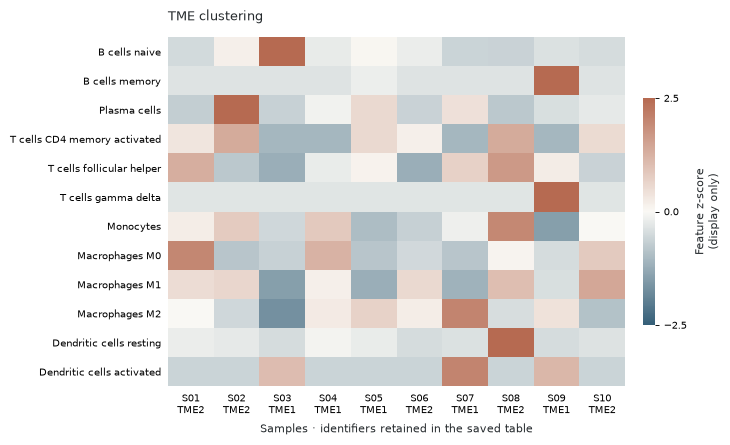

In [4]:
configure(2)
fig = plot_result(plot, 'TME clustering', 2, groups=groups)
for extension in ('png', 'pdf', 'svg'):
    fig.savefig(Path('figures') / (slug + '.' + extension), dpi=200, bbox_inches='tight')
review = Path('review/extensions')
review.mkdir(parents=True, exist_ok=True)
fig.savefig(review / (slug + '-round-2.png'), dpi=120, bbox_inches='tight')
plt.show()

Interpretation: the heatmap highlights relative patterns within each displayed feature. Colors are not cell fractions, statistical significance or cross-feature effect sizes. Full numeric outputs are saved separately. Runtime depends on hardware, input size, parameters and cache state.